<a href="https://colab.research.google.com/github/lynnlinshuo-lgtm/is4487-labs/blob/main/assignment_14_api_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 4487 Assignment 14: Exploring APIs with yfinance

In this assignment, you will:
- Choose an industry you're interested in (such as tech, airlines, or retail)
- Use the `yfinance` Python package as an API to collect historical stock price data
- Clean and prepare the data for analysis
- Explore trends, volatility, and relationships between companies
- Summarize your findings and recommendation in a business memo

## Why This Matters

APIs (Application Programming Interfaces) allow businesses to pull live, real-world data from external sources directly into their analytics tools. Financial analysts, investment firms, and business leaders use APIs like `yfinance` to monitor company performance, assess market trends, and build models based on dynamic data.

This assignment helps you gain hands-on experience with one of the most common API workflows in business analytics: fetching, cleaning, analyzing, and interpreting financial data to support better decision-making.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_14_api.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Step 1: Choose an Industry and Find Company Ticker Symbols

Visit the following website to explore U.S. stock sectors and industries:  
https://www.tradingview.com/markets/stocks-usa/sectorandindustry-sector/

### Do the following
Choose one industry you are interested in (for example: Airlines, Technology, Fast Food, Retail, Energy, etc.).  
Write the names and ticker symbols of 4 public companies in that industry.

**Example:**
- Industry: Technology  
- Tickers: AAPL, MSFT


In [9]:
# Replace this list with your selected tickers
tickers = ["AAPL", "MSFT", "NVDA", "GOOGL"]

## Step 2: Use yfinance to Collect Historical Stock Data

Follow the steps below to use the `yfinance` API to collect historical stock price data.

### Do the following

1. Make sure the `yfinance` package is installed by running the code cell below.
2. Import any additional Python libraries that you might need to explore or visualize the data.
3. Use the `yf.download()` function to pull **5 years of daily adjusted close prices** for the companies you selected in Step 1.
    - Choose a start date and an end date that span the past 5 years (e.g., `"2020-01-01"` to `"2025-12-31"`).
    - Only select the **'High'** column, which represents the daily high
4. Preview the first few rows of the dataset using `.head()` to confirm that the data has loaded correctly.



In [10]:
# Import necessary libraries
!pip install yfinance

import yfinance as yf
import pandas as pd

In [11]:
# Download adjusted close prices

df = yf.download(
    tickers,
    start="2021-01-01",
    end="2026-01-01",
    progress=False
)

/tmp/ipykernel_2344/614681169.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(


In [12]:
df.head()

Price            Close                                          High  \
Ticker            AAPL      GOOGL        MSFT       NVDA        AAPL   
Date                                                                   
2021-01-04  125.740875  85.547935  207.956131  13.060797  129.821791   
2021-01-05  127.295471  86.237808  208.156738  13.350876  128.004784   
2021-01-06  123.010521  85.386848  202.759369  12.563801  127.334355   
2021-01-07  127.208054  87.937241  208.529297  13.290371  127.897930   
2021-01-08  128.306030  89.101425  209.799835  13.223391  128.869587   

Price                                                Low             \
Ticker          GOOGL        MSFT       NVDA        AAPL      GOOGL   
Date                                                                  
2021-01-04  87.349950  213.028695  13.597631  123.166009  84.606780   
2021-01-05  86.573826  208.749025  13.389470  124.788620  85.090481   
2021-01-06  86.432084  206.809785  13.191767  122.796757  84.059620   
2021-01-07  88.109707  209.532350  13.323986  124.234815  85.579145   
2021-01-08  89.177253  210.716916  13.367061  126.537625  87.287009   

Price                                    Open                         \
Ticker            MSFT       NVDA        AAPL      GOOGL        MSFT   
Date                                                                   
2021-01-04  205.204904  12.910404  129.734346  87.226548  212.579710   
2021-01-05  206.055113  13.034403  125.235584  85.496382  207.545356   
2021-01-06  202.463233  12.535416  124.098768  84.265792  202.682944   
2021-01-07  204.154101  12.834710  124.720639  85.579145  204.469333   
2021-01-08  207.325649  12.989584  128.675246  88.077008  208.901864   

Price                     Volume                                 
Ticker           NVDA       AAPL     GOOGL      MSFT       NVDA  
Date                                                             
2021-01-04  13.051584  143301900  37324000  37130100  560640000  
2021-01-05  13.047101   97664900  20360000  23823000  322760000  
2021-01-06  13.169357  155088000  46588000  35930700  580424000  
2021-01-07  12.915384  109578200  41936000  27694500  461480000  
2021-01-08  13.308797  105158200  35484000  22956200  292528000

## Step 3: Clean the Data

The data you pulled may contain missing values.

### Do the following

1. Check the dataset for missing values using `.isnull().sum()`.
2. Fill any missing values using a forward fill method.
3. Recheck for missing values to confirm they have been handled.



In [13]:
# Check missing values
df.isnull().sum()

# Fill missing values using forward fill method
df = df.ffill()

# Check missing values again
df.isnull().sum()

Price   Ticker
Close   AAPL      0
        GOOGL     0
        MSFT      0
        NVDA      0
High    AAPL      0
        GOOGL     0
        MSFT      0
        NVDA      0
Low     AAPL      0
        GOOGL     0
        MSFT      0
        NVDA      0
Open    AAPL      0
        GOOGL     0
        MSFT      0
        NVDA      0
Volume  AAPL      0
        GOOGL     0
        MSFT      0
        NVDA      0
dtype: int64

## Step 4: Calculate Daily Returns

To better understand price movement, we will calculate the daily percentage change for each stock.

### Do the following

1. Use the `.pct_change()` method to calculate daily returns.
2. Drop any rows with missing values that may result from this calculation.
3. Preview the returns DataFrame to confirm it's correct.


In [14]:
# Calculate daily returns

returns = df.pct_change()

# Drop rows with missing values

returns = returns.dropna()

# Preview the returns dataframe

returns.head()

Price          Close                                    High            \
Ticker          AAPL     GOOGL      MSFT      NVDA      AAPL     GOOGL   
Date                                                                     
2021-01-05  0.012363  0.008064  0.000965  0.022210 -0.013996 -0.008885   
2021-01-06 -0.033661 -0.009868 -0.025929 -0.058953 -0.005238 -0.001637   
2021-01-07  0.034123  0.029869  0.028457  0.057830  0.004426  0.019410   
2021-01-08  0.008631  0.013239  0.006093 -0.005040  0.007597  0.012116   
2021-01-11 -0.023249 -0.023106 -0.009699  0.025966 -0.018548 -0.008325   

Price                                Low                                \
Ticker          MSFT      NVDA      AAPL     GOOGL      MSFT      NVDA   
Date                                                                     
2021-01-05 -0.020090 -0.015309  0.013174  0.005717  0.004143  0.009605   
2021-01-06 -0.009290 -0.014766 -0.015962 -0.012115 -0.017432 -0.038282   
2021-01-07  0.013165  0.010023  0.011711  0.018077  0.008351  0.023876   
2021-01-08  0.005653  0.003233  0.018536  0.019957  0.015535  0.012067   
2021-01-11 -0.007571  0.040235 -0.013284 -0.005156 -0.001383  0.024574   

Price           Open                                  Volume            \
Ticker          AAPL     GOOGL      MSFT      NVDA      AAPL     GOOGL   
Date                                                                     
2021-01-05 -0.034677 -0.019835 -0.023682 -0.000343 -0.318468 -0.454506   
2021-01-06 -0.009077 -0.014393 -0.023428  0.009370  0.587960  1.288212   
2021-01-07  0.005011  0.015586  0.008814 -0.019285 -0.293445 -0.099854   
2021-01-08  0.031708  0.029188  0.021678  0.030461 -0.040336 -0.153853   
2021-01-11 -0.024466 -0.000079 -0.000960  0.004209 -0.045395 -0.019389   

Price                           
Ticker          MSFT      NVDA  
Date                            
2021-01-05 -0.358391 -0.424301  
2021-01-06  0.508236  0.798315  
2021-01-07 -0.229225 -0.204926  
2021-01-08 -0.171092 -0.366109  
2021-01-11  0.003271  0.771947

## Step 5: Explore the Data Visually and Statistically

In this step, you will create visualizations and metrics to help understand stock behavior. Don’t interpret or explain anything here — just create the outputs so you can use them in your reflection later.

### Do the following
1. Create a line chart showing stock prices over the 5-year period.
2. Calculate the standard deviation of daily returns for each stock (volatility).
3. Create a correlation matrix of the daily returns between companies.




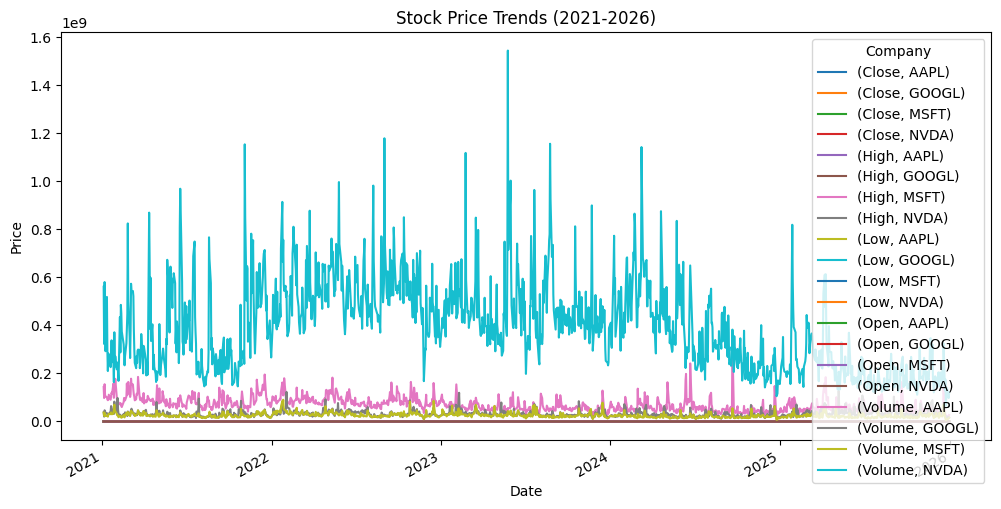

Stock Volatility:
Price   Ticker
Close   AAPL      0.017552
        GOOGL     0.019620
        MSFT      0.016198
        NVDA      0.032898
High    AAPL      0.015260
        GOOGL     0.017840
        MSFT      0.014077
        NVDA      0.029001
Low     AAPL      0.016214
        GOOGL     0.018374
        MSFT      0.014983
        NVDA      0.030355
Open    AAPL      0.018164
        GOOGL     0.019827
        MSFT      0.016480
        NVDA      0.033918
Volume  AAPL      0.333683
        GOOGL     0.397203
        MSFT      0.342025
        NVDA      0.342194
dtype: float64


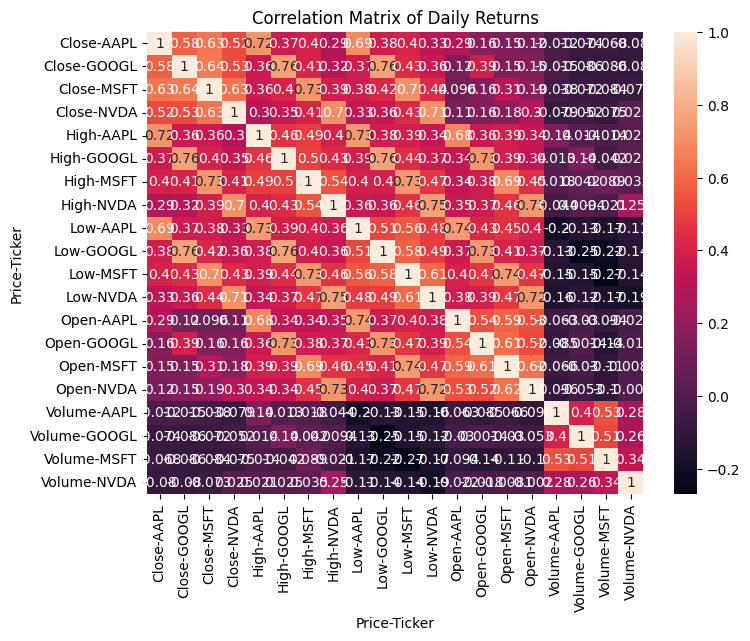

In [15]:
# Import visualization library

import matplotlib.pyplot as plt
import seaborn as sns


# 1. Create line chart showing stock prices over 5 years

df.plot(figsize=(12,6))

plt.title("Stock Price Trends (2021-2026)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(title="Company")
plt.show()


# 2. Calculate volatility (standard deviation of daily returns)

volatility = returns.std()

print("Stock Volatility:")
print(volatility)


# 3. Create correlation matrix of daily returns

correlation_matrix = returns.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True
)

plt.title("Correlation Matrix of Daily Returns")
plt.show()

## Step 6: Write a Stakeholder Recommendation Memo

Now that you’ve completed your analysis, it’s time to turn your work into a clear, professional memo for a business audience.

### Scenario

You’ve been asked by a stakeholder (an investor, executive, or client) to evaluate whether it's a good time to invest in a particular industry. They’ve asked you to use recent stock performance data from several leading companies in that industry to help guide their decision.

### Your Task

Use the results from your code in Steps 2–5 to write a **multi-paragraph business memo** that:

1. **Introduces the industry you analyzed** and names the companies you included.
2. **Summarizes major trends** you observed in the stock prices over the last 5 years.
3. **Discusses key metrics**, such as volatility and correlations between companies.
4. **Presents your investment recommendation** — based on your evidence — and explains why you would or wouldn’t advise investing in this industry now.
5. **Suggests future analytics or data sources** that could strengthen or update your recommendation going forward.

This final section should show that you understand how real-world decisions evolve. Think about:
- What **additional data** might help (e.g., earnings reports, economic indicators, sentiment analysis)?
- What **types of models** could be applied (e.g., forecasting, classification, risk modeling)?
- How often should the analysis be updated?

### Format & Expectations

- Write **2–4 paragraphs** in business memo format (not bullet points).
- Use **specific, data-driven evidence** from your own analysis.
- Keep your writing professional and clear — imagine your reader is a client or executive, not a data analyst.
- Your memo should be written **entirely in your own words**. Do not copy from examples, online sources, or AI tools. Your writing should reflect your understanding and your interpretation of the results.
- You do not need to include charts in the memo — the code cells above already display them.



### ✍️ Add memo here:
Memo: Investment Analysis of the Technology Industry

This memo evaluates the recent performance of the technology industry using historical stock data from four major companies: Apple (AAPL), Microsoft (MSFT), NVIDIA (NVDA), and Google (GOOGL). Using five years of stock price data collected through the yfinance API, this analysis examines price trends, daily returns, volatility, and relationships between companies to provide an investment recommendation.

Over the five-year period, all four technology companies showed overall growth trends, although their stock prices experienced periods of fluctuation due to market conditions. NVIDIA demonstrated stronger price growth compared with the other companies, while Apple, Microsoft, and Google showed more stable long-term performance. The volatility analysis showed differences in risk levels among companies, indicating that higher growth opportunities may also involve greater price fluctuations. The correlation analysis suggested that technology companies often move together because they are influenced by similar market and economic factors.

Based on the analysis, investing in the technology industry can provide attractive growth opportunities, but investors should consider risk differences between companies. A balanced investment approach focusing on companies with strong historical performance and managing exposure to higher-volatility stocks may be appropriate. Rather than investing based only on past performance, investors should continue monitoring market conditions and company-specific factors.

Future analysis could be strengthened by incorporating additional data sources, such as earnings reports, economic indicators, market sentiment data, and industry trends. More advanced models, including forecasting models, risk prediction models, and machine learning approaches, could also be applied to improve investment decision-making. Regular updates of the analysis would help stakeholders adjust their strategies as market conditions change.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [16]:
!jupyter nbconvert --to html "assignment_14_api.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_14_api.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execu